# Import Required Libraries
Import the necessary libraries, including pandas, numpy, chemotools, and scikit-learn.

In [3]:
%pip install chemotools


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
from chemotools.derivative import SavitzkyGolay
from chemotools.scatter import StandardNormalVariate
from chemotools.feature_selection import RangeCut
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA 
from sklearn.cross_decomposition import PLSRegression

# Load Data and first Visualisation
Load the spectra and classes data from the CSV files using pandas.

In [2]:
# Load the combined dataset correctly
# This file is comma-separated and already contains the class column
combined_data = pd.read_csv('/workspaces/data-importation-and-visualisation-Georgis12/data/combined_data.csv')

# Separate spectra (features) and labels
spectra = combined_data.drop(columns='class')
labels = combined_data[['class']].rename(columns={'class': 'Labels'})

print(f"The spectra dataset has {spectra.shape[0]} samples")
print(f"The spectra dataset has {spectra.shape[1]} features")
print(labels.head())

The spectra dataset has 160 samples
The spectra dataset has 224 features
   Labels
0  canola
1  canola
2  canola
3  canola
4  canola


In [23]:
#Explore 

print(f"The spectra dataset has {spectra.shape[0]} samples") 
print(f"The spectra dataset has {spectra.shape[1]} features") 

The spectra dataset has 160 samples
The spectra dataset has 0 features


Text(0.5, 1.0, 'Number of samples per class')

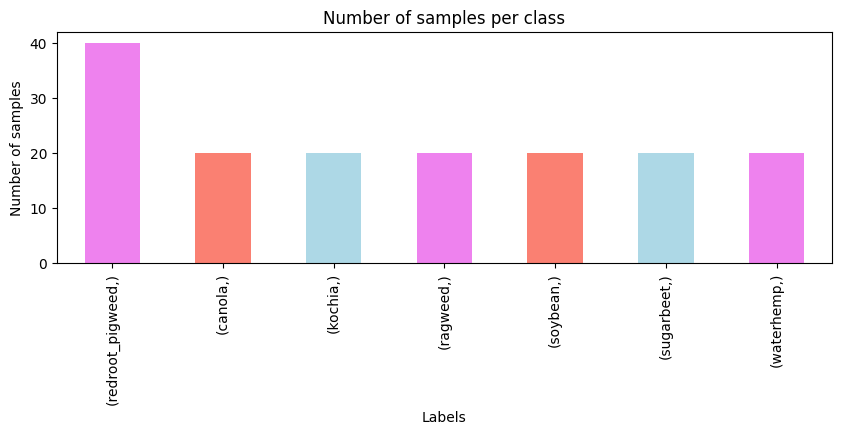

In [29]:
#plot the sample sizes

fig, ax = plt.subplots(figsize=(10, 3)) 
labels.value_counts().plot.bar(color=['Violet', 'Salmon', 'LightBlue'], ax=ax) 
ax.set_ylabel("Number of samples") 
ax.set_title("Number of samples per class") 


In [3]:
# Create colors automatically for the classes present in the file
unique_labels = labels["Labels"].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
color_dict = dict(zip(unique_labels, colors))

labels.iloc[1]

Labels    canola
Name: 1, dtype: str

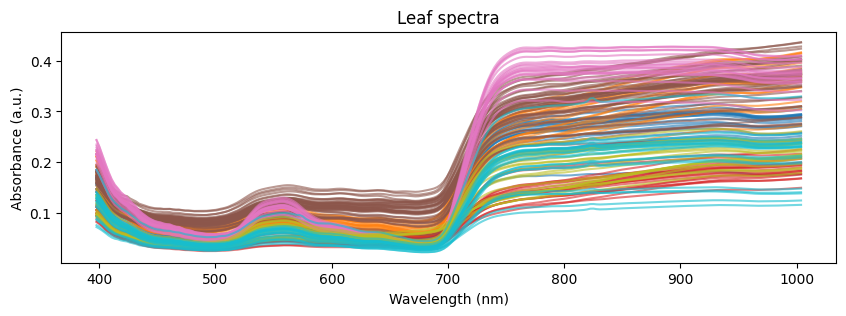

In [31]:
# Plot each spectrum using the labels from combined_data.csv
unique_labels = labels["Labels"].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
color_dict = dict(zip(unique_labels, colors))

x_axis = spectra.columns.astype(float)

fig, ax = plt.subplots(figsize=(10, 3))
for i, (_, row) in enumerate(spectra.iterrows()):
    label = labels.iloc[i]["Labels"]
    ax.plot(x_axis, row.astype(float).values, color=color_dict.get(label, "gray"), alpha=0.6)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Absorbance (a.u.)")
ax.set_title("Leaf spectra")
plt.show()

In [32]:
# get the values of the spectra and classes
X = spectra.values
# Make a LabelEncoder object 
le = LabelEncoder() 
# Fit the LabelEncoder object 
le.fit(labels.values.ravel()) 
# Transform the labels 
labels_encoded = le.transform(labels.values.ravel()) 
print(labels_encoded)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6]


In [33]:
# Make a OneHotEncoder object 
enc = OneHotEncoder(handle_unknown='ignore')
# Fit the LabelEncoder object 
enc.fit(labels.values)
# Transform the labels 
labels_dummy = enc.transform(labels.values).toarray()
print(labels_dummy)
print(enc.inverse_transform(labels_dummy))

[[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
[['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['redroot_pigweed']
 ['redroot_pigweed']
 ['redroot_pigweed']
 ['redroot_pigweed']
 ['redroot_pigweed']

# PCA

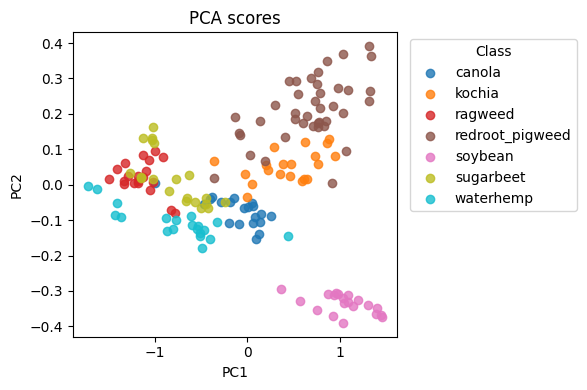

In [35]:
# Standardize the data
spectra_scaled = StandardScaler(with_std=False).fit_transform(spectra)

# Make a PCA object
pca = PCA(n_components=2)

# Fit and transform the data
spectra_pca = pca.fit_transform(spectra_scaled)

# Make a dataframe with the PCA scores
spectra_pca_df = pd.DataFrame(data=spectra_pca, columns=["PC1", "PC2"], index=spectra.index)

# Add the labels to the dataframe
spectra_pca_df = pd.concat([spectra_pca_df, labels], axis=1)

# Plot the PCA scores with legend
fig, ax = plt.subplots(figsize=(6, 4))
for class_name in spectra_pca_df["Labels"].unique():
    subset = spectra_pca_df[spectra_pca_df["Labels"] == class_name]
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        label=class_name,
        color=color_dict.get(class_name, "gray"),
        alpha=0.8,
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA scores")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Compare different preprocessing methods
Below we generate several spectral preprocessing alternatives so you can compare them and later decide which one gives the best class separation or classification performance.

Methods included:
- Raw spectra
- Mean centering
- SNV
- Savitzky-Golay smoothing
- 1st derivative
- 2nd derivative
- SNV + 1st derivative

In [7]:
# Create different preprocessing versions to compare later
x_axis = spectra.columns.astype(float)

preprocessed_datasets = {
    "Raw spectra": spectra.to_numpy(dtype=float),
    "Mean centered": StandardScaler(with_std=False).fit_transform(spectra),
    "SNV": StandardNormalVariate().fit_transform(spectra),
    "Savitzky-Golay smoothing": SavitzkyGolay(
        window_length=11,
        polyorder=3,
        deriv=0,
    ).fit_transform(spectra),
    "1st derivative": SavitzkyGolay(
        window_length=11,
        polyorder=3,
        deriv=1,
    ).fit_transform(spectra),
    "2nd derivative": SavitzkyGolay(
        window_length=11,
        polyorder=3,
        deriv=2,
    ).fit_transform(spectra),
    "SNV + 1st derivative": make_pipeline(
        StandardNormalVariate(),
        SavitzkyGolay(window_length=11, polyorder=3, deriv=1),
    ).fit_transform(spectra),
}

print("Available preprocessing methods:")
for method_name in preprocessed_datasets:
    print("-", method_name)

Available preprocessing methods:
- Raw spectra
- Mean centered
- SNV
- Savitzky-Golay smoothing
- 1st derivative
- 2nd derivative
- SNV + 1st derivative


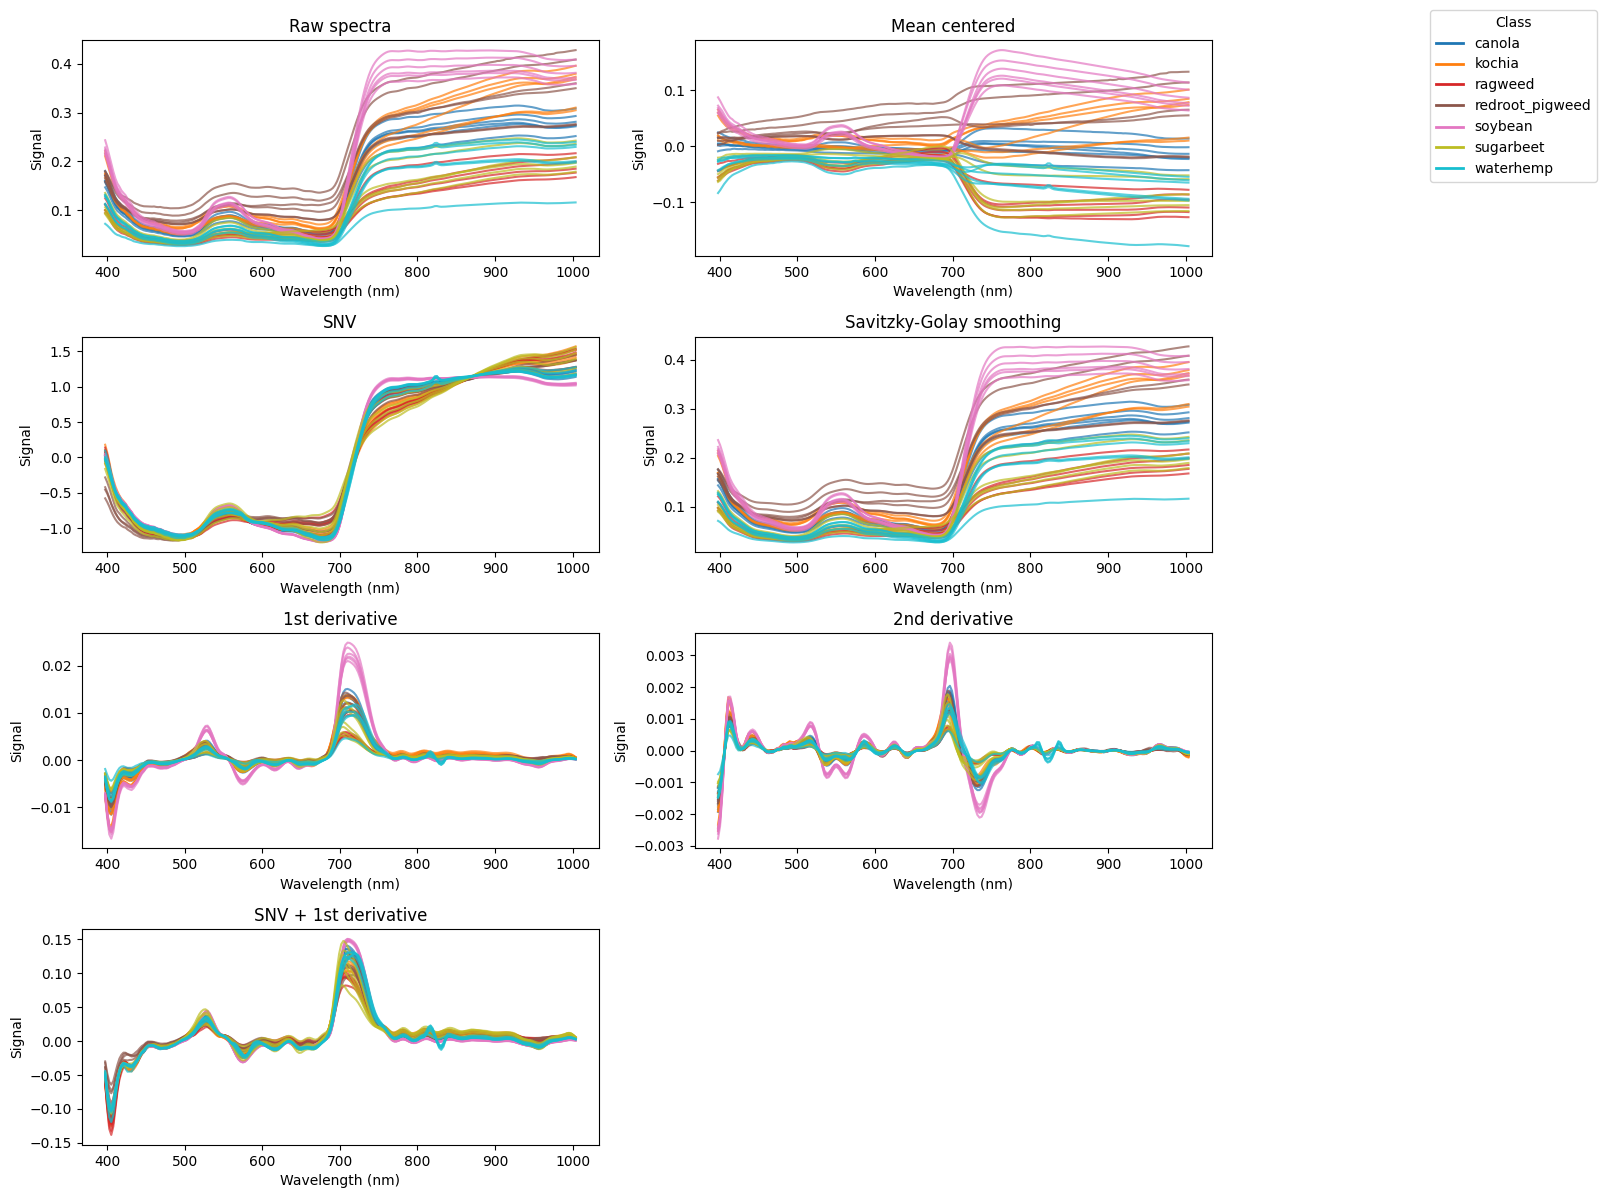

In [13]:
# Compare the effect of each preprocessing method on the spectra
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=False)
axes = axes.flatten()

# Plot a balanced subset so every species appears in the legend and in the curves
samples_per_class = 6
sample_indices = []
label_array = labels["Labels"].to_numpy()
for class_name in unique_labels:
    class_positions = np.where(label_array == class_name)[0][:samples_per_class]
    sample_indices.extend(class_positions.tolist())

for ax, (method_name, processed_data) in zip(axes, preprocessed_datasets.items()):
    for i in sample_indices:
        label = labels.iloc[i]["Labels"]
        ax.plot(
            x_axis,
            np.asarray(processed_data[i], dtype=float),
            color=color_dict.get(label, "gray"),
            alpha=0.7,
        )
    ax.set_title(method_name)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Signal")

# Hide any empty subplot
for ax in axes[len(preprocessed_datasets):]:
    ax.axis("off")

# Shared legend for the class colors
legend_handles = [
    axes[0].plot([], [], color=color_dict.get(class_name, "gray"), lw=2, label=class_name)[0]
    for class_name in unique_labels
]
fig.legend(legend_handles, unique_labels, title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

In [9]:
# Choose one preprocessing method for the next modelling steps
selected_method = "SNV + 1st derivative"  # change this name to test another method
X_preprocessed = preprocessed_datasets[selected_method]

print(f"Selected preprocessing: {selected_method}")
print(f"Processed data shape: {X_preprocessed.shape}")

Selected preprocessing: SNV + 1st derivative
Processed data shape: (160, 224)


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=52285e31-ca1b-4138-adce-00a746385bb7' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>

# PCA comparison for each preprocessing method
In this section, PCA is applied to every preprocessing method and the separation between species is compared using the first two principal components. A higher silhouette score indicates better class separation in the PCA space.

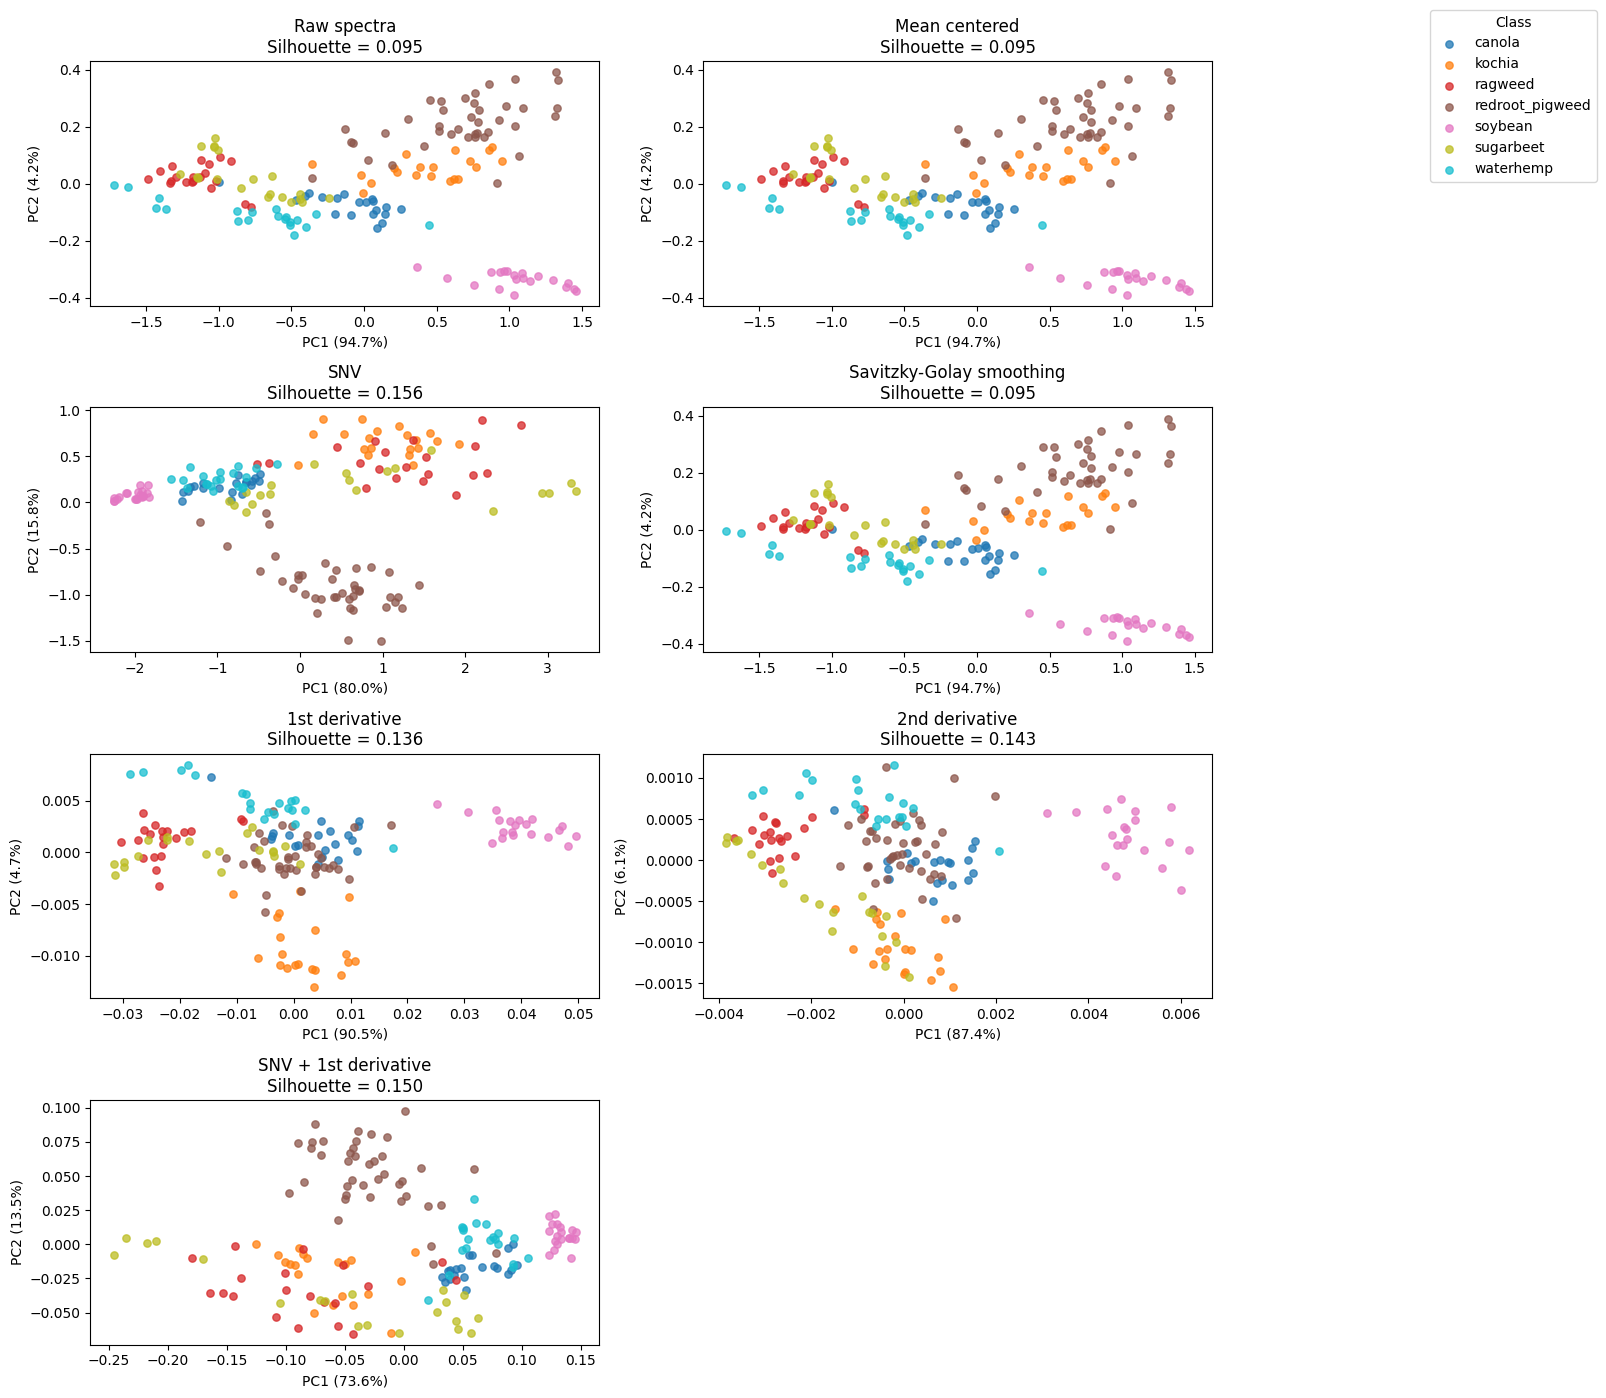

,Preprocessing,Silhouette score,Explained variance PC1 (%),Explained variance PC2 (%),Total explained variance (%)
2,SNV,0.156,80.007,15.773,95.780
6,SNV + 1st derivative,0.150,73.596,13.533,87.129
5,2nd derivative,0.143,87.406,6.094,93.499
4,1st derivative,0.136,90.546,4.748,95.293
1,Mean centered,0.095,94.667,4.170,98.837
0,Raw spectra,0.095,94.667,4.170,98.837
3,Savitzky-Golay smoothing,0.095,94.672,4.167,98.839


Best preprocessing based on PCA separation: SNV


In [10]:
# Apply PCA to each preprocessing method and compare the separation quality
from sklearn.metrics import silhouette_score

pca_results = []
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()
class_labels = labels["Labels"].to_numpy()

for ax, (method_name, processed_data) in zip(axes, preprocessed_datasets.items()):
    pca_model = PCA(n_components=2)
    pca_scores = pca_model.fit_transform(processed_data)
    explained_var = pca_model.explained_variance_ratio_
    silhouette = silhouette_score(pca_scores, class_labels)

    for class_name in np.unique(class_labels):
        mask = class_labels == class_name
        ax.scatter(
            pca_scores[mask, 0],
            pca_scores[mask, 1],
            label=class_name,
            color=color_dict.get(class_name, "gray"),
            alpha=0.75,
            s=28,
        )

    ax.set_title(f"{method_name}\nSilhouette = {silhouette:.3f}")
    ax.set_xlabel(f"PC1 ({explained_var[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({explained_var[1] * 100:.1f}%)")

    pca_results.append({
        "Preprocessing": method_name,
        "Silhouette score": silhouette,
        "Explained variance PC1 (%)": explained_var[0] * 100,
        "Explained variance PC2 (%)": explained_var[1] * 100,
        "Total explained variance (%)": explained_var[:2].sum() * 100,
    })

for ax in axes[len(preprocessed_datasets):]:
    ax.axis("off")

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

pca_comparison_df = pd.DataFrame(pca_results).sort_values(by="Silhouette score", ascending=False)
display(pca_comparison_df.round(3))

best_method = pca_comparison_df.iloc[0]["Preprocessing"]
print(f"Best preprocessing based on PCA separation: {best_method}")

# Classification training for each preprocessing method
Below, the same classifier is trained on every preprocessing version using stratified cross-validation. This helps compare which preprocessing leads to better species identification performance.

,Preprocessing,Accuracy,Weighted F1
5,2nd derivative,0.944,0.944
6,SNV + 1st derivative,0.938,0.937
4,1st derivative,0.894,0.896
1,Mean centered,0.888,0.889
0,Raw spectra,0.831,0.834
3,Savitzky-Golay smoothing,0.831,0.834
2,SNV,0.762,0.749


Best preprocessing based on classification accuracy: 2nd derivative

Classification report:
                 precision    recall  f1-score   support

         canola       0.95      0.95      0.95        20
         kochia       1.00      1.00      1.00        20
        ragweed       0.81      0.85      0.83        20
redroot_pigweed       0.95      1.00      0.98        40
        soybean       1.00      1.00      1.00        20
      sugarbeet       0.94      0.85      0.89        20
      waterhemp       0.95      0.90      0.92        20

       accuracy                           0.94       160
      macro avg       0.94      0.94      0.94       160
   weighted avg       0.94      0.94      0.94       160



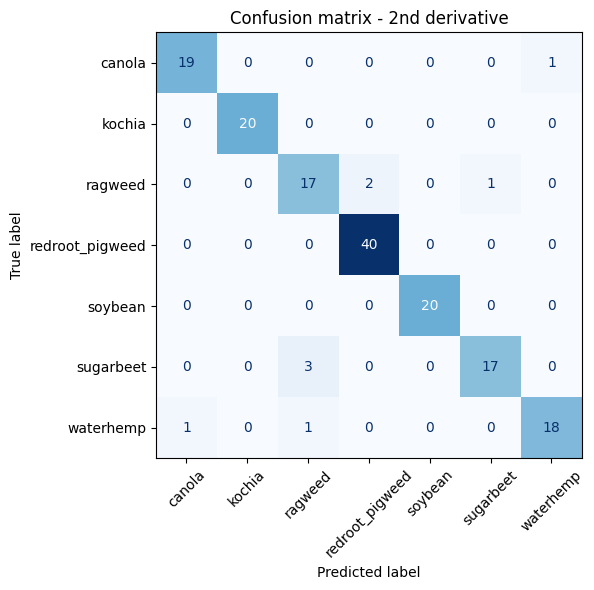

In [14]:
# Train and compare a classifier for each preprocessing method
from sklearn.svm import SVC
from sklearn.metrics import f1_score, ConfusionMatrixDisplay

class_labels = labels["Labels"].to_numpy()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
classification_results = []
predictions_by_method = {}

for method_name, processed_data in preprocessed_datasets.items():
    model = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced")
    y_pred_cv = cross_val_predict(model, processed_data, class_labels, cv=cv)
    predictions_by_method[method_name] = y_pred_cv

    classification_results.append({
        "Preprocessing": method_name,
        "Accuracy": accuracy_score(class_labels, y_pred_cv),
        "Weighted F1": f1_score(class_labels, y_pred_cv, average="weighted"),
    })

classification_comparison_df = pd.DataFrame(classification_results).sort_values(
    by=["Accuracy", "Weighted F1"], ascending=False
)
display(classification_comparison_df.round(3))

best_classification_method = classification_comparison_df.iloc[0]["Preprocessing"]
best_predictions = predictions_by_method[best_classification_method]

print(f"Best preprocessing based on classification accuracy: {best_classification_method}")
print()
print("Classification report:")
print(classification_report(class_labels, best_predictions))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    class_labels,
    best_predictions,
    display_labels=np.unique(class_labels),
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title(f"Confusion matrix - {best_classification_method}")
plt.tight_layout()
plt.show()